# Modelo para prever falha de maquinas num parque fabril

## Configurações do projeto

**Importar as bibliotecas e pacotes**

In [7]:
import pandas as pd
import numpy as np

**Lê arquivo com os dados**

In [12]:
file_id = "1er0sPjY51RymKrRkzZkjFOVwJ8PEZoAZ"

download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(download_url, sep=",", encoding="latin-1")


**Primeira visualização dos dados**

In [13]:
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


Podemos ver que a leitura do csv ocorreu de forma correta. As colunas estão preenchidas com valores que fazem sentido para cada um dos seus significados

## Fase 1: Análise Exploratória (EDA)

**Dimensões do dataset**

In [14]:
df.shape

(10000, 14)

A função `shape`  retorna o número de linhas e colunas. Podemos ver que no caso desse dataframe temos 10000 linhas e 14 colunas

**Tipos dos dados**

In [15]:
df.dtypes

udi                          int64
id_produto                  object
tipo                        object
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

O conjunto possui:
- 1 coluna de identificação
- 2 variáveis categóricas nominais (id_produto e tipo).
- 4 variáveis numéricas contínuas.
- 1 variável numérica discreta relacionada ao desgaste da ferramenta.
- 6 variaveis numericas discretas que são variáveis binárias (0/1).

**Resumo das colunas numéricas**

In [16]:
df.describe()

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


**PLOTS**

In [21]:
import seaborn as sns

In [32]:
# Configura cores usadas nos graficos do notebook
sns.set_theme(
    style="whitegrid",
    palette="flare",
    context="notebook"
)

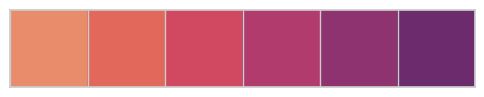

In [30]:
sns.palplot(sns.color_palette("flare"))

**histograma das variáveis preditoras**

Para o histograma usamos variaveis preditoras numéricas. Por isso das 6 variáveis preditoras:
- tipo
- temperatura_ar_k
- temperatura_processo_k
- velocidade_rotacao_rpm
- torque_nm
- desgaste_ferramenta_min

Não faremos histograma do tipo

In [38]:
type(cores)

seaborn.palettes._ColorPalette

In [41]:
for cor, _ in zip(cores, preditoras_numericas):
    print(cor)

(0.91262605, 0.52893336, 0.40749715)
(0.87199254, 0.3633634, 0.35974223)
(0.75861834, 0.25356035, 0.40663694)
(0.60407977, 0.21017746, 0.43913439)
(0.44584668, 0.17360625, 0.43114133)


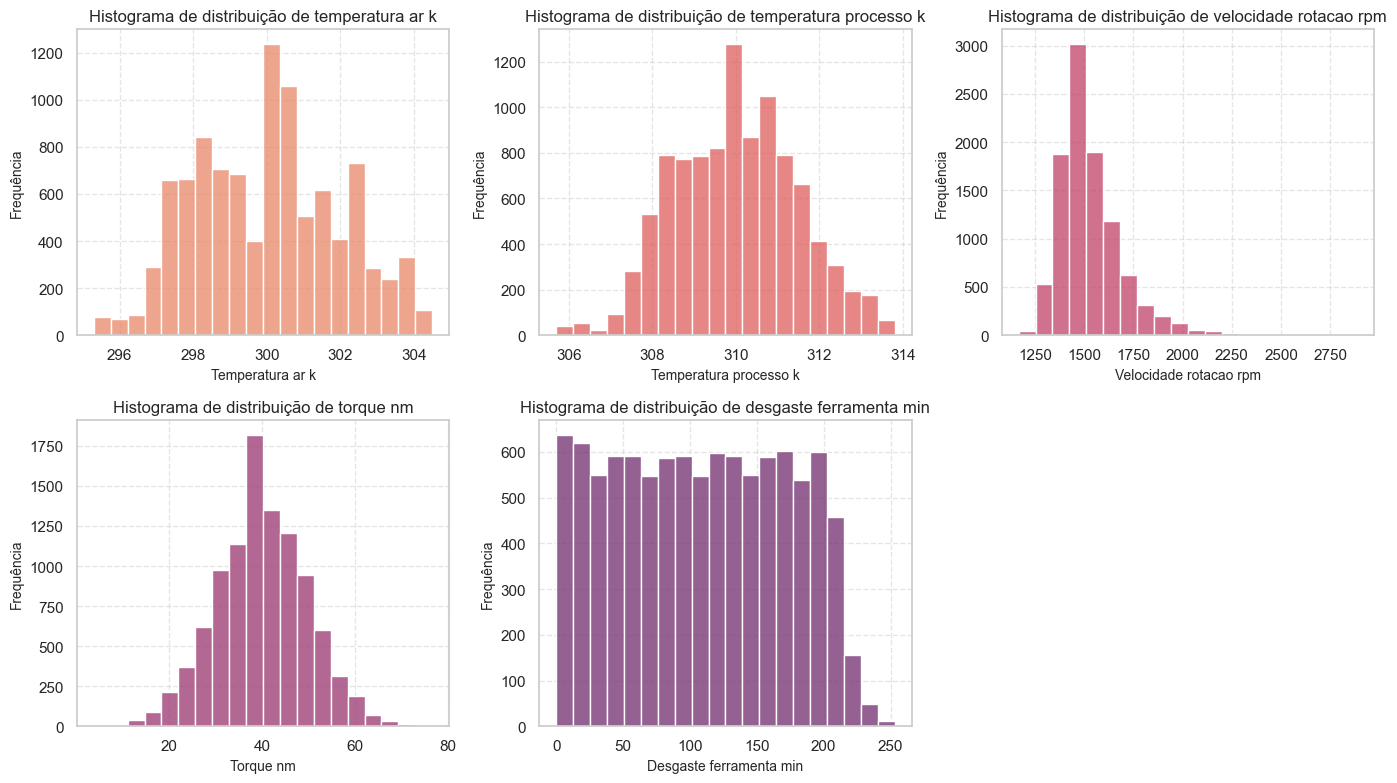

In [104]:
import matplotlib.pyplot as plt

preditoras_numericas = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min'
]

# Define o tamanho da figura e cria subplots (2 linhas e 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
# Transforma a matriz 2x3 em um vetor 1D
axes = axes.flatten()

# Define a paleta de cor com a quantidade de cores igual ao número de preditoras
cores = sns.color_palette("flare", len(preditoras_numericas))

# Faz uma iteração para cada variável preditora e plota o histograma correspondente.
# O zip() é usado para iterar simultaneamente sobre os eixos, as colunas e as cores.
for ax, preditora, cor in zip(axes, preditoras_numericas, cores):
    sns.histplot(
        data=df,
        x=preditora,
        bins=20,
        color=cor,
        edgecolor="white",
        ax=ax
    )

    # Ajustes esteticos
    preditora_name = preditora.replace("_", " ")
    ax.set_title(f"Histograma de distribuição de {preditora_name}", fontsize=12)
    ax.set_xlabel(preditora_name.capitalize(), fontsize=10)
    ax.set_ylabel("Frequência", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

# Remove o último subplot vazio
fig.delaxes(axes[-1])

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
plt.show()

**Grafico de barras para variável preditiva categórica: tipo**

In [54]:
dict_categorias = {
    'L': 'baixo',
    'M': 'medio',
    'H': 'alto'
}

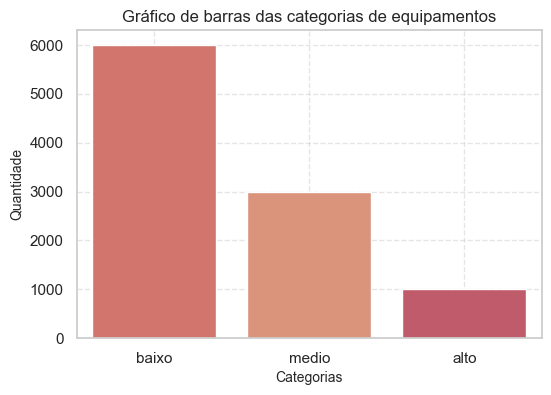

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x=df["tipo"].map(dict_categorias),
    order=dict_categorias.values(),
    hue = 'tipo'
)

plt.title("Gráfico de barras das categorias de equipamentos", fontsize=12)
plt.xlabel("Categorias", fontsize=10)
plt.ylabel("Quantidade", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend().remove()



plt.show()

**Gráfico de barras da variável alvo**

In [68]:
df['falha_maquina'].groupby(df['falha_maquina']).count()

falha_maquina
0    9661
1     339
Name: falha_maquina, dtype: int64

In [81]:
339/ (9661+399)

0.03369781312127237

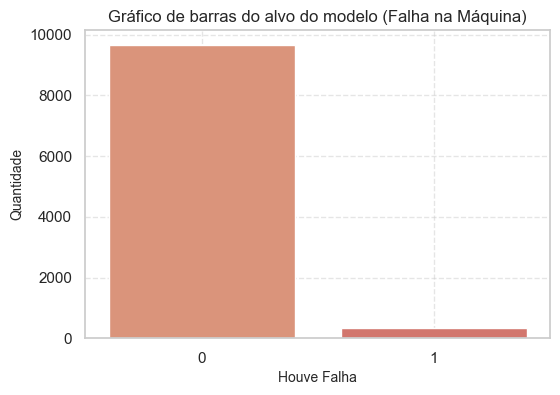

In [71]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='falha_maquina',
    hue = 'falha_maquina'
)

plt.title("Gráfico de barras do alvo do modelo (Falha na Máquina)", fontsize=12)
plt.xlabel("Houve Falha", fontsize=10)
plt.ylabel("Quantidade", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend().remove()

plt.show()

**Mapa de calor com a correlação de Pearson**

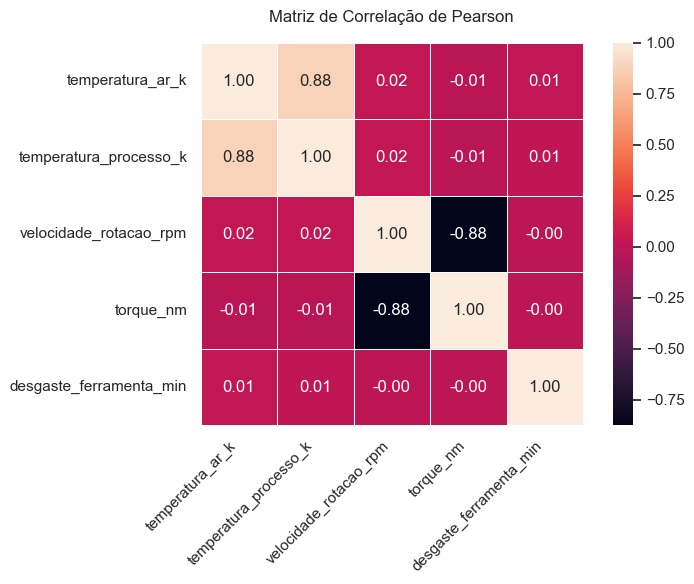

In [78]:
# Calcula a correlação de Pearson
corr = df[preditoras_numericas].corr(method="pearson")

# Cria o gráfico
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,          # Mostra os valores da correlação
    fmt=".2f",           # Duas casas decimais
    linewidths=0.5,
    square=True,
)

plt.title("Matriz de Correlação de Pearson", fontsize=12, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()



**CONCLUSÃO**

`Análise numérica`

Analisando as metricas obtidas com o `describe()` vemos que as temperaturas têm um desvio papdrão bem pequeno e valores mínimos e maximos bem proximos da média, indicando que não há grande dispersão dos dados. O torque fica em segundo lugar, com valores que vão de 3.8 a 76.6 nm. O desgaste da ferramenta é o que possui o maior desvio padrão, o que é explicado no histograma depois, mas evidencia um range muito grande de valores possíveis.

`Gráficos`

A partir dos graficos conseguimos obter insights sobre alguns comportamentos e características do nosso modelo.

**Gráfico 1:**
A partir dos histogramas podemos ver que as variáveis de temperatura (tanto ar como processo) e torque apresentam comportamento próximo ao de uma distribuição normal, o que indica que a maioria das máquinas opera com valores próximos da mediana. No caso das temperaturas a dispersão é pequena (a maioria das medidas se encontra numa faixa de 4K), enquanto para o torque fica numa faixa de 25 a 55 mn A velocidade de rotação apresenta uma forte assimetria positiva, indicando que altas rotações são pouco frequentes. Por fim, o desgaste da ferramenta encontra-se distribuído de forma relativamente homogênea, sugerindo que o conjunto de dados contempla máquinas em diferentes estágios de uso.

**Gráfico 2:**
O gráfico de barras indica que a maior parte das máquinas é do tipo baixo, seguida de medio e alto


**Gráfico 3:**
Mostra que a falha ocorre em somente 3% dos casos, o que e muito menor do que o número de casos de não falha. Isso momstra que temos um desbalanceamento da variavel alvo, que talvez tenha que ser tratada posteriormente.

**Gráfico 4:**
Mostra que a maior parte das variaveis é descorrelacionada. Somente torque e velocidade de rotação e temperatura do processo e temperatura do ar são fortemente correlacionadas (no primeiro caso inversamente correlacionadas). Como o valor dessas correlações relevantes ultrapassa 0.8 é possível que tenhamos que dropar algumas variáveis futuramente para que a mesma informação não seja considerada 2 vezes no treinamento do modelo

## Fase 2: Tratamento e limpeza dos dados

**Linhas duplicadas**

In [83]:
# Quantidade de linhas duplicadas
df.duplicated().sum()

np.int64(0)

Não existem duas linhas iguais no dataframe

MAS temos o código de identificação do registro. Será que é houveram 2 registros para o mesmo produto e, consequentemente, cada registro tenha um udi diferente?

In [89]:
colunas = [col for col in df.columns if col != "udi"]

df.duplicated(subset=colunas).sum()

np.int64(0)

A resposta é não. Realmente temos 1 registro por produto. Isso pode ser corroborado através do fato de que o núero de id_produtos únicos é igual ao número de linhas

In [90]:
df['id_produto'].nunique() == df.shape[0]

True

**Identificação de dados ausentes**

In [92]:
df.isnull().sum()

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

Temos 4 colunas com 500 valores nulos

**Imputação**

Num geral substituimos pela média quando temos uma distribuição simétrica dos dados de uma variável e temos poucos outliers. Quando temos uma distribuição assimétrica ou muitos outlires substituímos pela mediana.

Vimos nos histogramas anteriores que o torque(nm) e as temperaturas do ar e do processo possuem distribuições simétricas, logo substituiremos os valores nulos pela média. Já no caso da velocidade de rotação, temos uma distribuição assimétrica. Logo, a subtituiremos pela mediana.

In [96]:
df['temperatura_ar_k'] = df['temperatura_ar_k'].fillna(df['temperatura_ar_k'].mean())
df['temperatura_processo_k'] = df['temperatura_processo_k'].fillna(df['temperatura_processo_k'].mean())
df['velocidade_rotacao_rpm'] = df['velocidade_rotacao_rpm'].fillna(df['velocidade_rotacao_rpm'].median())
df['torque_nm'] = df['torque_nm'].fillna(df['torque_nm'].mean())

Um jeito de checar se essa é realmente a melhor escolha é calculando a média e a mediana para cada uma das variáveis. Se os valores forem próximos significa que a distribuição é simétrica e a média é uma boa escolha. Caso sejam muito diferentes, a distribuição é assimétrica e, por consequencia, a mediana é a melhor escolha.

Veja a seguir que os valores da média e mediana são próximos para o torque(nm) e as temperaturas do ar e do processo enquanto são diferentes para a velocidade de rotação, corroborando assim, a nossa escolha

In [93]:
df[[
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm"
]].agg(["mean", "median"])

,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm
mean,300.002158,310.000895,1539.245263,39.974168
median,300.100000,310.100000,1504.000000,40.100000


**Gráficos boxplot**

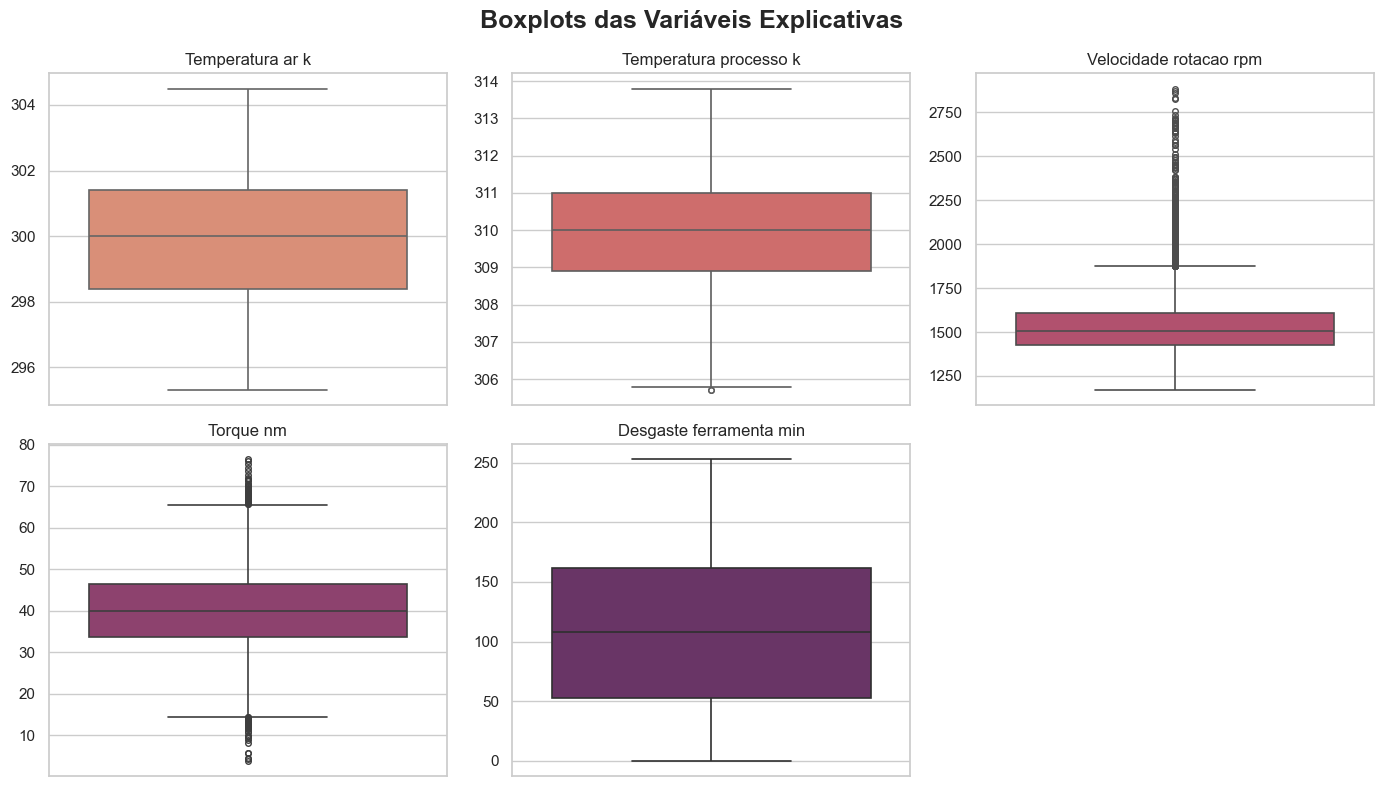

In [108]:

# Boxplot é um gráfico apropriado para variáveis numéricas.

# Cria a figura
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Cores da paleta flare
cores = sns.color_palette("flare", len(preditoras_numericas))

# Gera um boxplot para cada variável
for ax, coluna, cor in zip(axes, preditoras_numericas, cores):
    sns.boxplot(
        y=df[coluna],
        ax=ax,
        color=cor,
        linewidth=1.2,
        fliersize=4
    )
    
    # Ajustes esteticos
    preditora_name = coluna.replace("_", " ")
    ax.set_title(preditora_name.capitalize(), fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Remove o último subplot vazio
fig.delaxes(axes[-1])

plt.suptitle("Boxplots das Variáveis Explicativas", fontsize=18, fontweight="bold")
plt.tight_layout()

plt.show()


**Conclusão:**

Vemos que `Torque` e `Velocidade de rotação` apresentam bastante outliers. Enquanto o torque possui uma distribuição simétrica (possui outliers acima e abaixo dos limites superiores) vemos que a velocidade de rotação é antissimétrica (possui outliers somente acima do limite superior). O restante das variáveis não possui outliers e são bem simétricas

### Fase 3: Feature engineering

**Criação de nova feature**

A potência em um sistema rotacional é dada por:
$$P = \tau \cdot \omega$$

onde:

* $P$ = potência (W)
* $\tau$ = torque (N·m)
* $\omega$ = velocidade angular (rad/s)

Como no dataset a velocidade está em **RPM (rotações por minuto)**, precisamos convertê-la para rad/s:

$$ \omega = \frac{2\pi \cdot v_{RPM}}{60}$$

Substituindo na equação, obtemos que a potência em W é dada por:

$$ \boxed{P = \frac{2\pi \cdot v_{RPM} \cdot \tau}{60}}$$



In [109]:
df['potencia_w'] = 2 * np.pi* df['velocidade_rotacao_rpm']*df['torque_nm'] /60

Verificação se não há nulos

In [112]:
df['potencia_w'].isnull().sum() 

np.int64(0)

### Fase 4: Divisão e balanceamento dos dados

**Separação de variaveis**

In [113]:
df.columns

Index(['udi', 'id_produto', 'tipo', 'temperatura_ar_k',
       'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm',
       'desgaste_ferramenta_min', 'falha_maquina', 'falha_twf', 'falha_hdf',
       'falha_pwf', 'falha_osf', 'falha_rnf', 'potencia_w'],
      dtype='object')

In [121]:
# Variaveis preditoras
X = df[[
    'tipo', 
    'temperatura_ar_k',
    'temperatura_processo_k', 
    'velocidade_rotacao_rpm', 
    'torque_nm',
    'desgaste_ferramenta_min',
    'potencia_w'
]]

#Variável alvo
y = df['falha_maquina']

In [122]:
X.head(3)

,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,potencia_w
0,M,298.1,308.6,1551.0,42.8,0,6951.590560
1,L,298.2,308.7,1408.0,46.3,3,6826.722724
2,L,298.1,308.5,1498.0,49.4,5,7749.387543


`NOTA:` Perceba que a variável `tipo` se encontra como string. Os modelos de clusterização KNN e Arvore de decisão não aceitam variáveis categóricas em string. Assim, temos que substituí-las por um valor numérico.

Como essa variavel apresenta uma ordem: $Low < Medium < High$, ela é classificada como variável categórica ordinal. Por isso, será realizada uma codificação ordinal, atribuindo os valores 0, 1, 2 para cada categoria.

In [123]:
mapeamento = {
    'L': 0,
    'M': 1,
    'H': 2
}

X['tipo'] = X['tipo'].map(mapeamento)

/tmp/ipykernel_775527/734639267.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['tipo'] = X['tipo'].map(mapeamento)


In [124]:
X.head(3)

,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,potencia_w
0,1,298.1,308.6,1551.0,42.8,0,6951.590560
1,0,298.2,308.7,1408.0,46.3,3,6826.722724
2,0,298.1,308.5,1498.0,49.4,5,7749.387543


**Separar treino e teste**

In [ ]:
# importamos uma função para realizar a divisão entre treino e teste
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    # Mantem a mesma quantidade de cada classe no conjunto de treino e teste
    stratify=y
)

In [149]:
y_treino.value_counts()

falha_maquina
0    7729
1     271
Name: count, dtype: int64

In [141]:
y_treino.value_counts(normalize = True)

falha_maquina
0    0.966125
1    0.033875
Name: proportion, dtype: float64

In [142]:
y_teste.value_counts(normalize = True)

falha_maquina
0    0.966
1    0.034
Name: proportion, dtype: float64

Peceba que tanto treino quanto teste têm a mesma proporção de eventos de falha e não falha. Se o `stratify = y` essa divisão é feita de forma aleatória e podemos ficar (proporcionalmente) com mais eventos de falha do que de não falha em um grupo. 

**Técnica de reamostragem**

Já tinhamos visto no gráfico de barras que existe uma proporção muito maior de máquinas em funcionamento do que falhadas. Essa proporção se manteve nos dados de treino e teste e faz com que o modelo tenda a prever que todas as máquinas não falharão. Para resolver esse problema, vamos usar a técnica `SMOTE` para ajustar as proporções. 

In [143]:
# Para aplicar essa tecnica vamos usar uma biblioteca chamada imbalanced-learn, que fornece várias técnicas para lidar com conjuntos de dados desbalanceados.
from imblearn.over_sampling import SMOTE

# Cria objeto SMOTE
smote = SMOTE(random_state=42)

# Aplica smote na base de treino
X_treino_bal, y_treino_bal = smote.fit_resample(
    X_treino,
    y_treino
)

In [144]:
y_treino_bal.value_counts(normalize = True)

falha_maquina
0    0.5
1    0.5
Name: proportion, dtype: float64

In [145]:
y_treino_bal.value_counts()

falha_maquina
0    7729
1    7729
Name: count, dtype: int64

In [148]:
X_treino.shape

(8000, 7)

In [147]:
X_treino_bal.shape

(15458, 7)

Veja que funcionou. Agora a base de treino tem exatamente a mesma quantidade de máquinas com e sem falha. Note que a quantidade de máquinas com falha se equiparou a quantidade sem falha, o que significa que a função criou dados de falha até obter a mesma quantidade de dados sem falha. Esse processo de aumentar uma classe se chama `oversampling`